In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_pickle('raf_slightly_mod.pkl')

C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_24160\2024837230.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Niitro_musics\AppData\Local\Temp\ipykernel_24160\2024837230.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


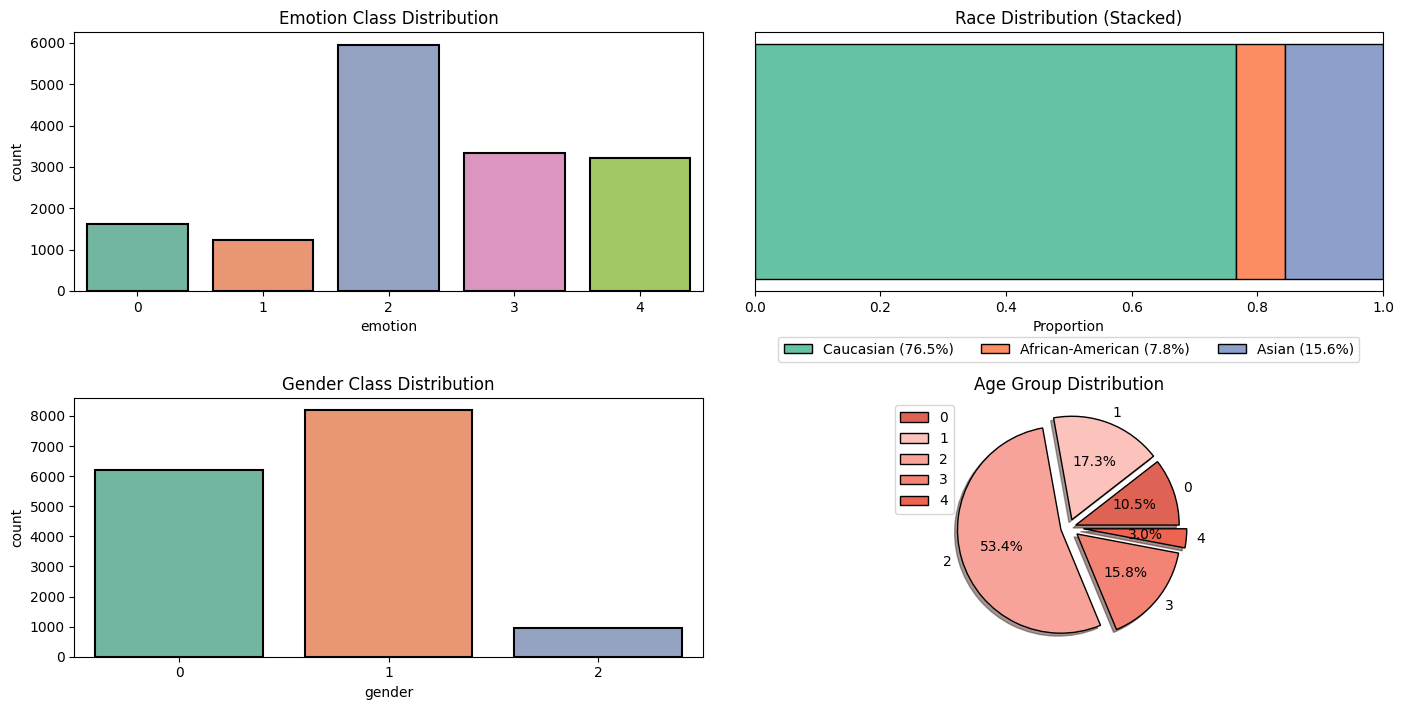

In [6]:
cols = ['emotion', 'race', 'gender', 'age']
n_cols = 2
n_rows = (len(cols) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12*1.2, 6*1.2))
axes = axes.flatten()

agerangeplot_raf = df['age'].value_counts().sort_index().values
agerangelab_raf = [str(i) for i in df['age'].value_counts().sort_index().index]
wedgeprops={'edgecolor': 'black'}

set2_colors = sns.color_palette('Set2', 8)
race_colors = set2_colors[:3]
my_old_pallet = ['#df6354','#fbc3bc','#f7a399','#f38375','#ef6351']

for i, col in enumerate(cols):
    if col == 'age':
        axes[i].pie(
            agerangeplot_raf,
            labels=agerangelab_raf,
            autopct='%1.1f%%',
            colors=my_old_pallet,
            explode=[0.07,0.08,0.08,0.1,0.14],
            shadow=True,
            wedgeprops=wedgeprops
        )
        axes[i].legend(loc='upper left', bbox_to_anchor=(-0.2, 1))
        axes[i].set_title('Age Group Distribution')
    
    elif col == 'race':
        race_counts = df['race'].value_counts(normalize=True).sort_index()
        race_labels = ['Caucasian', 'African-American', 'Asian']

        left = 0
        for j, label in enumerate(race_labels):
            axes[i].barh(
                y=0,
                width=race_counts[j],
                left=left,
                color=race_colors[j],
                edgecolor='black',
                height=0.6,
                label=f"{label} ({race_counts[j]*100:.1f}%)"
            )
            left += race_counts[j]

        axes[i].set_xlim(0, 1)
        axes[i].set_yticks([])
        axes[i].set_xlabel("Proportion")
        axes[i].set_title("Race Distribution (Stacked)")
        axes[i].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

    else:
        sns.countplot(
            x=col,
            data=df,
            ax=axes[i],
            palette='Set2',
            edgecolor='black',
            linewidth=1.5
        )
        axes[i].set_title(f"{col.capitalize()} Class Distribution")

for j in range(i+1, len(axes)): axes[j].axis('off')

plt.tight_layout()
plt.show()


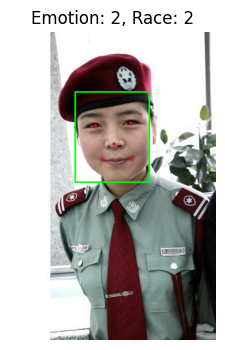

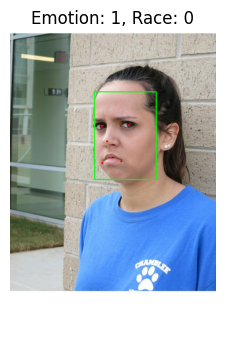

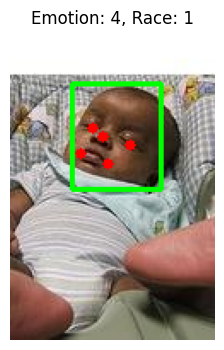

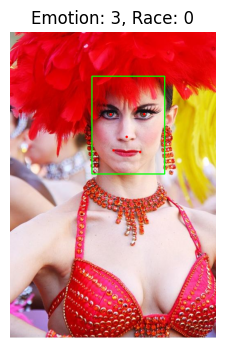

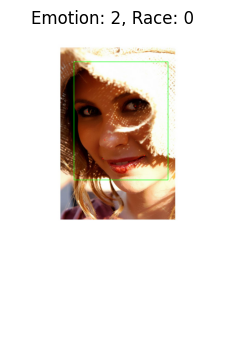

In [7]:
import cv2
def show_image_with_landmarks(row, figsize=(4,4)):
    img = cv2.imread(row['image_path'])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    x_min, y_min, x_max, y_max = map(int, row['bbox'])
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), (0,255,0), 2)

    for (x, y) in row['landmarks_manual']:
        cv2.circle(img, (int(x), int(y)), 3, (255,0,0), -1)

    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.title(f"Emotion: {row['emotion']}, Race: {row['race']}")
    plt.axis('off')
    plt.show()

for _ in range(5): show_image_with_landmarks(df.sample(1).iloc[0])
